## Trimming the Short Term Memory when the context window of the model exceeds

First import all the required modules


In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

load_dotenv()

True

Define the model

In [2]:
model = ChatOpenAI()

Now, while building the graph, we will set a max_tokebn size such that we can keep track of them while chatting.

If max_tokens = 150, then we will keep just the last 150 tokens worth of messages only in the short term memory erazing the previous ones systematically.

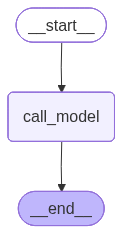

In [3]:
MAX_TOKENS = 150

def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last", #here we can define whether to trim last 'n' messages or first 'n' messages                     
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    #Here we will print the current token count for our convenience
    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    #Also, all the previous messages before the current message in memory
    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

Testing, thread-1

In [4]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Dragon."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Dragon.


'Hello, Dragon! Nice to meet you. How can I assist you today?'

In [5]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 41
Hi, my name is Dragon.
Hello, Dragon! Nice to meet you. How can I assist you today?
I am learning LangGraph.


"That's great! LangGraph is a language learning platform that utilizes graph theory to help users visualize and understand the connections between words and concepts. Is there anything specific you would like to learn or discuss about LangGraph?"

In [6]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 121
Hi, my name is Dragon.
Hello, Dragon! Nice to meet you. How can I assist you today?
I am learning LangGraph.
That's great! LangGraph is a language learning platform that utilizes graph theory to help users visualize and understand the connections between words and concepts. Is there anything specific you would like to learn or discuss about LangGraph?
Can you explain short term memory?


'Short-term memory, also known as working memory, is a system responsible for the temporary storage and manipulation of information that is currently being used. It has a limited capacity and duration, typically holding around 5-9 items for a brief period of time (around 15-30 seconds) before either transferring the information to long-term memory through encoding or forgetting it.\n\nShort-term memory is crucial for tasks such as remembering phone numbers, following instructions, and solving problems. It involves three main components: the phonological loop (for verbal information), the visuospatial sketchpad (for visual information), and the central executive (which coordinates and controls these two components). \n\nTo improve short-term memory, strategies like chunking (grouping information into manageable chunks), rehearsal (repeating information), and visualization can be helpful. Regular practice and mental exercises can also strengthen short-term memory capacity and retention.'

In [7]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


"I'm sorry, as an AI assistant, I am not able to know your name unless you provide it to me."

In [8]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What am I learning?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 45
What is my name?
I'm sorry, as an AI assistant, I am not able to know your name unless you provide it to me.
What am I learning?


'You are learning about different topics through the questions you ask and the conversations we have. If there is a specific subject or topic you are interested in learning more about, feel free to ask, and I will do my best to help you learn more about it.'

The above, we see that it remmoved the whole messages so, that we lost a lot of content. There is one more option to remove partial messages.

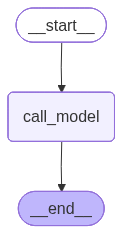

In [9]:
MAX_TOKENS = 150

def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last", #here we can define whether to trim last 'n' messages or first 'n' messages                     
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS,
        allow_partial=True
    )

    #Here we will print the current token count for our convenience
    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    #Also, all the previous messages before the current message in memory
    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

Testing again

In [10]:
config = {"configurable": {"thread_id": "chat-2"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Dragon."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Dragon.


'Nice to meet you, Dragon! How can I assist you today?'

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 39
Hi, my name is Dragon.
Nice to meet you, Dragon! How can I assist you today?
I am learning LangGraph.


"That's great to hear! LangGraph is an intriguing language learning platform. Do you have any specific questions or topics you would like to discuss regarding LangGraph? I'm here to help!"

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 104
Hi, my name is Dragon.
Nice to meet you, Dragon! How can I assist you today?
I am learning LangGraph.
That's great to hear! LangGraph is an intriguing language learning platform. Do you have any specific questions or topics you would like to discuss regarding LangGraph? I'm here to help!
Can you explain short term memory?


"Short-term memory is a type of memory that temporarily holds information in our mind for a brief period of time. It is also referred to as working memory, as it involves actively manipulating and processing information in our minds.\n\nShort-term memory has limited capacity and duration, meaning it can only hold a certain amount of information for a short period of time before either forgetting it or transferring it to long-term memory. The capacity of short-term memory is generally thought to be around 7 plus or minus 2 items, according to research by psychologist George Miller.\n\nShort-term memory plays a crucial role in tasks such as learning, problem-solving, and reasoning. It helps us hold onto information temporarily while we use it to perform cognitive tasks. However, without rehearsal or encoding into long-term memory, information held in short-term memory is quickly forgotten. That's why strategies like repetition, chunking, and association can help improve the retention of 

Now, when it exceeded the context window, it didnt remove all messages, just kept enough to make room for some more etc. Even the current message is split and not complete

In [13]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 124

Short-term memory plays a crucial role in tasks such as learning, problem-solving, and reasoning. It helps us hold onto information temporarily while we use it to perform cognitive tasks. However, without rehearsal or encoding into long-term memory, information held in short-term memory is quickly forgotten. That's why strategies like repetition, chunking, and association can help improve the retention of information in short-term memory.
What is my name?


"I'm sorry, but I'm not able to remember or know personal information about individuals unless it has been shared with me in the course of our conversation. My purpose is to provide information and assistance to the best of my abilities. If there is anything specific you'd like to ask me or discuss, please feel free to do so."

Lets print the entire convo once

In [14]:
for item in graph.get_state({"configurable": {"thread_id": "chat-2"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Dragon.
------------------------------------------------------------------------------------------------------------------------
Nice to meet you, Dragon! How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's great to hear! LangGraph is an intriguing language learning platform. Do you have any specific questions or topics you would like to discuss regarding LangGraph? I'm here to help!
------------------------------------------------------------------------------------------------------------------------
Can you explain short term memory?
------------------------------------------------------------------------------------------------------------------------
Short-term memory is a type of memory that temporarily holds informatio